## 0 · Setup

Seaborn theme, project palette, and small helpers reused across the notebook.


In [1]:
import json
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats as st
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ---- Theme ----
sns.set_theme(style="whitegrid", context="notebook", rc={
    "figure.dpi": 110, "figure.autolayout": True,
    "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.labelsize": 10, "axes.edgecolor": "#dddddd",
    "grid.color": "#eef0f2", "grid.linewidth": 0.7,
    "font.family": "sans-serif",
})
PALETTE = {
    "tech": "#4C72B0", "fund": "#C44E52", "sent": "#55A868",
    "news": "#8172B3", "sector": "#DDB967", "vix": "#937860",
    "beat": "#55A868", "miss": "#C44E52",
    "low": "#C44E52", "mod": "#DDB967", "high": "#55A868",
}
sns.set_palette(list(PALETTE.values())[:6])


# ---- Helpers ----
def annotate(ax, fmt="{:.1f}", dy=0.0, color="black", **kw):
    "Add value labels above each bar in a barplot."
    for p in ax.patches:
        h = p.get_height()
        if h == h:  # nan-safe
            ax.annotate(fmt.format(h), (p.get_x() + p.get_width()/2, h + dy),
                         ha="center", va="bottom", fontsize=8, color=color, **kw)


def annotate_h(ax, fmt="{:.0f}", dx=0.5, color="black", **kw):
    "Add value labels to the right of horizontal bars."
    for p in ax.patches:
        w = p.get_width()
        if w == w:
            ax.annotate(fmt.format(w), (w + dx, p.get_y() + p.get_height()/2),
                         ha="left", va="center", fontsize=8, color=color, **kw)


def pct(x, pos):
    return f"{x:.0%}"


def find(rel_path):
    roots = [Path("."), Path("src"), Path("/Users/richardpears/github/Post-Earnings-Forecast")]
    for r in roots:
        p = (r / rel_path) if not str(rel_path).startswith("src") else (r / Path(*Path(rel_path).parts[1:]))
        # simpler: try joined
        for cand in [Path(rel_path), r / rel_path,
                     r / "src" / "modeling" / rel_path if "modal_" in rel_path else None,
                     r / "src" / "data" / "model_staging" / Path(rel_path).name]:
            if cand and cand.exists():
                return str(cand)
    return None

RESULTS = find("modal_tabnet_outputs/results.parquet") or find("src/modeling/modal_tabnet_outputs/results.parquet")
SUMMARY = find("modal_tabnet_outputs/per_fold_summary.parquet") or find("src/modeling/modal_tabnet_outputs/per_fold_summary.parquet")
TECH    = find("tech_modeling_table.parquet") or find("src/data/model_staging/tech_modeling_table.parquet")
FUND    = find("fundamentalIndicators/modeling_fundamentals.parquet") or find("src/data/model_staging/fundamentalIndicators/modeling_fundamentals.parquet")
NZ      = find("nz_sentiment.parquet") or find("src/data/model_staging/nz_sentiment.parquet")
FB      = find("finbert_tx_agg_weighted.parquet") or find("src/data/model_staging/finbert_tx_agg_weighted.parquet")
VIX     = find("ingestion/data/index_data.parquet") or find("src/ingestion/data/index_data.parquet")
print("Resolved paths OK:", all([RESULTS, SUMMARY, TECH, FUND, NZ, FB, VIX]))


Resolved paths OK: True


## 1 · Load & Tidy

Load all staged Parquet sources once and assemble a **tidy events frame**
(one row per earnings event) for seaborn, plus the TabNet predictions table.


In [2]:
results = pl.read_parquet(RESULTS)
summary = pl.read_parquet(SUMMARY)
tech    = pl.read_parquet(TECH)
fund    = pl.read_parquet(FUND)
nz      = pl.read_parquet(NZ)
finbert = pl.read_parquet(FB)
vix     = pl.read_parquet(VIX)

print(f"events={len(tech):,}  symbols={tech['symbol'].n_unique()}  "
      f"predictions={len(results):,}  folds={len(summary)}")

# ---- Tidy events frame (pandas, for seaborn) ----
ev = (
    tech.select(["symbol", "earnings_date", "entry_price",
                 "target_return", "target_class"])
    .join(
        fund.select(["symbol", "reportedDate", "surprisePercentage",
                     "reportedEPS", "estimatedEPS", "gross_margin", "roe"])
            .with_columns(pl.when(pl.col("surprisePercentage").is_null())
                          .then(0).otherwise(pl.col("surprisePercentage"))
                          .cast(pl.Float64).alias("eps_surprise_pct")),
        left_on=["symbol", "earnings_date"], right_on=["symbol", "reportedDate"],
        how="left")
    .with_columns(
        (pl.col("eps_surprise_pct") > 0).alias("beat"),
        pl.col("earnings_date").dt.year().alias("year"),
    )
    .join(
        finbert.select(["symbol", "reportedDate", "pos_prob", "neg_prob"]),
        left_on=["symbol", "earnings_date"], right_on=["symbol", "reportedDate"],
        how="left")
    .join(
        nz.select(["symbol", "reportedDate",
                   "overall_sentiment_score_pre", "overall_sentiment_score_post"])
          .rename({"overall_sentiment_score_pre": "news_pre",
                   "overall_sentiment_score_post": "news_post"}),
        left_on=["symbol", "earnings_date"], right_on=["symbol", "reportedDate"],
        how="left")
).to_pandas()

ev["beat_label"] = np.where(ev["beat"], "Beat", "Miss")
class_names = {0: "Low (<2%)", 1: "Moderate (2-4%)", 2: "Strong (≥4%)"}
ev["class_label"] = ev["target_class"].map(class_names)

# ATR columns (t-10 … t+1) for the volatility slide
atr_cols = [c for c in tech.columns if c.startswith("atr_t")]
ev_atr = tech.select(["symbol", "earnings_date"] + atr_cols).to_pandas()

# TabNet predictions → pandas
pred = results.to_pandas()
print("tidy frames ready:", ev.shape, ev_atr.shape, pred.shape)


events=24,048  symbols=503  predictions=9,937  folds=20
tidy frames ready: (24048, 19) (24048, 14) (9937, 12)


---

## Part 1: The Problem — Post-Earnings Drift as an Unsolved Prediction Challenge

Post-earnings announcement drift (PEAD) describes the tendency for stock prices
to continue moving in the direction of an earnings surprise for days or weeks
after the announcement. First documented by Bernard & Thomas (1989) at ~25%
annualised abnormal return, it remains one of the most persistent anomalies in
financial markets. Despite decades of research, no single signal — price, earnings
estimates, text tone, or news sentiment — has proven sufficient to predict PEAD
consistently. The state-of-the-art benchmark (Hajek et al., 2025)
achieved 59.94% directional accuracy and a 0.40 Sharpe ratio on 24,821 events.

We start by understanding whether the drift we observe in S&P 500 data is
consistent across our three target classes, and how it has evolved over the
decade-long sample window.

### 1.1 — The drift trajectory: cumulative return around earnings events

Earnings events produce a measurable drift in stock prices that persists for
days after the announcement. Here we trace the **cumulative return**
(close / entry at t+1 − 1) from 10 days before the event through 10 days
after, split by our three target classes.

The chart shows what the models see during training: the feature window
(t−10 → t+1, shaded blue) and the target window (t+2 → t+10, shaded red)
where we measure the drift. The class separation visible in the target
window is what we're attempting to predict.

In [3]:
import bisect
import plotly.graph_objects as go

# Load daily close prices
DAILY = find("tech_daily_table.parquet") or find("src/data/model_staging/tech_daily_table.parquet")
daily = pl.read_parquet(DAILY)

# Build date-indexed lookups per symbol for fast slicing
symbols = tech["symbol"].unique().to_list()
daily_lookup = {}
for sym in symbols:
    df = daily.filter(pl.col("symbol") == sym).sort("date")
    if df.is_empty():
        continue
    daily_lookup[sym] = {
        "dates": df["date"].to_list(),
        "closes": df["close"].to_numpy()
    }

# Compute t-10 -> t+10 cumulative return per event
traj_rows = []
for row in tech.select(["symbol", "earnings_date", "entry_price", "target_class"]).iter_rows(named=True):
    sym = row["symbol"]
    if sym not in daily_lookup:
        continue
    info = daily_lookup[sym]
    dates = info["dates"]
    closes = info["closes"]
    earn_date = row["earnings_date"]
    entry_price = row["entry_price"]
    target_class = row["target_class"]

    t0 = bisect.bisect_left(dates, earn_date)
    if t0 >= len(dates) or dates[t0] != earn_date:
        continue
    if t0 - 10 < 0 or t0 + 10 >= len(dates):
        continue

    for offset in range(-10, 11):
        cum_ret = float(closes[t0 + offset] / entry_price - 1)
        traj_rows.append({
            "symbol": sym,
            "earnings_date": earn_date,
            "target_class": target_class,
            "day": offset,
            "cum_return": cum_ret
        })

traj = pl.DataFrame(traj_rows).to_pandas()
traj["class_label"] = traj["target_class"].map({0: "Low (<2%)", 1: "Moderate (2-4%)", 2: "Strong (>=4%)"})

# Mean trajectory per day per class
mean_traj = traj.groupby(["day", "class_label"], observed=True)["cum_return"].mean().reset_index()

cls_colors = {
    "Low (<2%)": PALETTE["low"],
    "Moderate (2-4%)": PALETTE["mod"],
    "Strong (>=4%)": PALETTE["high"],
}

fig = go.Figure()

for cls, color in cls_colors.items():
    d = mean_traj[mean_traj["class_label"] == cls]
    fig.add_trace(go.Scatter(
        x=d["day"], y=d["cum_return"],
        mode="lines+markers",
        name=cls,
        line=dict(color=color, width=2.2),
        marker=dict(size=5, color=color),
    ))

# Shaded feature window (t-10 to t+1)
fig.add_vrect(x0=-10.5, x1=1.5, fillcolor=PALETTE["tech"], opacity=0.08, layer="below",
              line_width=0, annotation_text="Feature window<br>t-10 -> t+1",
              annotation_position="top left", annotation_font_size=10,
              annotation_font_color=PALETTE["tech"])

# Shaded target window (t+2 to t+10)
fig.add_vrect(x0=1.5, x1=10.5, fillcolor=PALETTE["miss"], opacity=0.08, layer="below",
              line_width=0, annotation_text="Target window<br>t+2 -> t+10",
              annotation_position="top right", annotation_font_size=10,
              annotation_font_color=PALETTE["miss"])

# Buffer line at t+1
fig.add_vline(x=1, line_dash="dash", line_color="#999999", line_width=0.8)

fig.update_layout(
    title="Mean cumulative return around earnings -- class divergence emerges after t+1",
    xaxis_title="trading days relative to earnings (t)",
    yaxis_title="cumulative return (close / entry at t+1 - 1)",
    yaxis_tickformat=".0%",
    height=420,
    margin=dict(l=20, r=20, t=50, b=20),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
)

fig.show()


### 1.2 — Rolling 4-quarter drift by class

Quarterly means are noisy; a 4-quarter rolling window smooths the signal and
reveals whether the three classes consistently separate. Ribbons show
$\pm 1\,\sigma$ per rolling window.

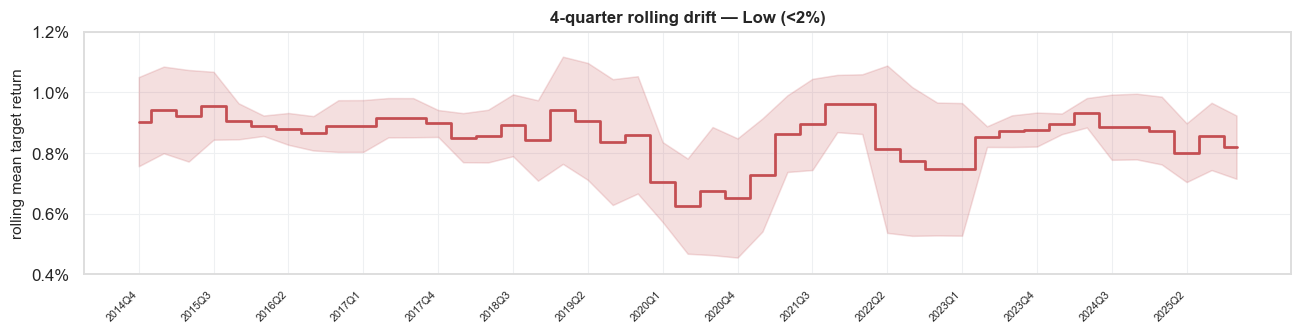

In [4]:
# ---- Low (<2%) ----
ev["yyyy_qq"] = pd.to_datetime(ev["earnings_date"]).dt.to_period("Q").astype(str)

qq_cls = (
    ev.query("2014 <= year <= 2025")
    .groupby(["yyyy_qq", "class_label"], observed=True)
    .agg(mean_return=("target_return", "mean"), std_return=("target_return", "std"))
    .reset_index()
)

d = qq_cls[qq_cls["class_label"] == "Low (<2%)"].sort_values("yyyy_qq").reset_index(drop=True)
roll_mean = d["mean_return"].rolling(4, min_periods=4).mean()
roll_std  = d["mean_return"].rolling(4, min_periods=4).std()

mask = roll_mean.notna()
q   = d["yyyy_qq"][mask]
mu  = roll_mean[mask]
up  = mu + roll_std[mask]
lo  = mu - roll_std[mask]

fig, ax = plt.subplots(figsize=(12, 3.2))

ax.fill_between(range(len(q)), lo, up, alpha=0.18, color=PALETTE["low"])
ax.plot(range(len(q)), mu, color=PALETTE["low"], lw=1.8, drawstyle="steps-mid")

ax.axhline(0, color="#999", lw=0.6)

step = max(1, len(q) // 12)
ax.set_xticks(range(0, len(q), step))
ax.set_xticklabels(q.iloc[::step], rotation=45, ha="right", fontsize=7)

ax.set_ylim(0.004, 0.012)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.set_title("4-quarter rolling drift — Low (<2%)")
ax.set_ylabel("rolling mean target return")
ax.set_xlabel("")

plt.tight_layout()
plt.show()


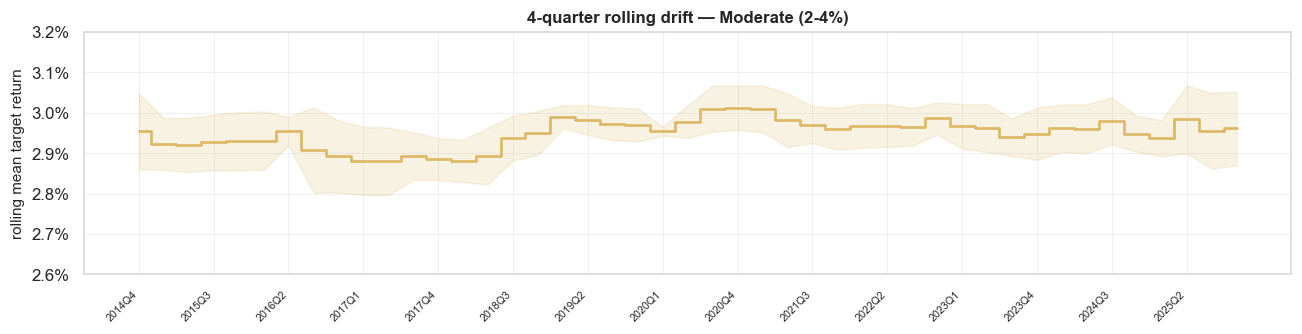

In [5]:
# ---- Moderate (2-4%) ----
ev["yyyy_qq"] = pd.to_datetime(ev["earnings_date"]).dt.to_period("Q").astype(str)

qq_cls = (
    ev.query("2014 <= year <= 2025")
    .groupby(["yyyy_qq", "class_label"], observed=True)
    .agg(mean_return=("target_return", "mean"), std_return=("target_return", "std"))
    .reset_index()
)

d = qq_cls[qq_cls["class_label"] == "Moderate (2-4%)"].sort_values("yyyy_qq").reset_index(drop=True)
roll_mean = d["mean_return"].rolling(4, min_periods=4).mean()
roll_std  = d["mean_return"].rolling(4, min_periods=4).std()

mask = roll_mean.notna()
q   = d["yyyy_qq"][mask]
mu  = roll_mean[mask]
up  = mu + roll_std[mask]
lo  = mu - roll_std[mask]

fig, ax = plt.subplots(figsize=(12, 3.2))

ax.fill_between(range(len(q)), lo, up, alpha=0.18, color=PALETTE["mod"])
ax.plot(range(len(q)), mu, color=PALETTE["mod"], lw=1.8, drawstyle="steps-mid")

ax.axhline(0, color="#999", lw=0.6)

step = max(1, len(q) // 12)
ax.set_xticks(range(0, len(q), step))
ax.set_xticklabels(q.iloc[::step], rotation=45, ha="right", fontsize=7)

ax.set_ylim(0.026, 0.032)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.set_title("4-quarter rolling drift — Moderate (2-4%)")
ax.set_ylabel("rolling mean target return")
ax.set_xlabel("")

plt.tight_layout()
plt.show()


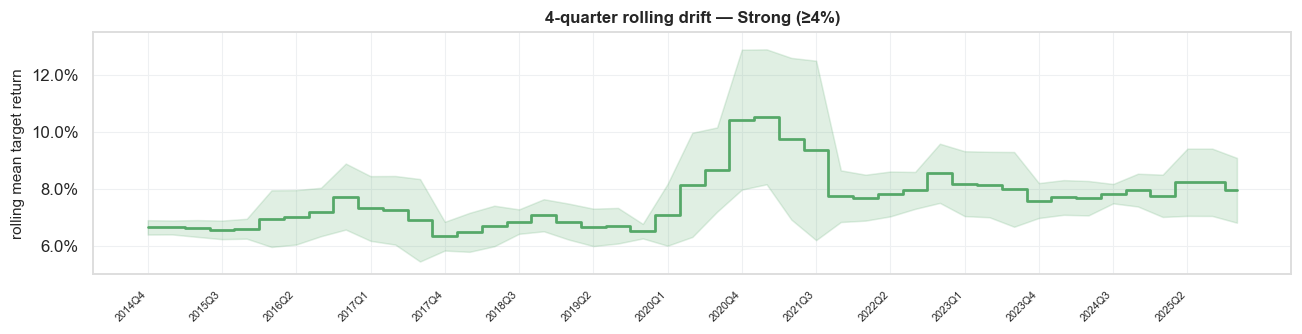

In [6]:
# ---- Strong (≥4%) ----
ev["yyyy_qq"] = pd.to_datetime(ev["earnings_date"]).dt.to_period("Q").astype(str)

qq_cls = (
    ev.query("2014 <= year <= 2025")
    .groupby(["yyyy_qq", "class_label"], observed=True)
    .agg(mean_return=("target_return", "mean"), std_return=("target_return", "std"))
    .reset_index()
)

d = qq_cls[qq_cls["class_label"] == "Strong (≥4%)"].sort_values("yyyy_qq").reset_index(drop=True)
roll_mean = d["mean_return"].rolling(4, min_periods=4).mean()
roll_std  = d["mean_return"].rolling(4, min_periods=4).std()

mask = roll_mean.notna()
q   = d["yyyy_qq"][mask]
mu  = roll_mean[mask]
up  = mu + roll_std[mask]
lo  = mu - roll_std[mask]

fig, ax = plt.subplots(figsize=(12, 3.2))

ax.fill_between(range(len(q)), lo, up, alpha=0.18, color=PALETTE["high"])
ax.plot(range(len(q)), mu, color=PALETTE["high"], lw=1.8, drawstyle="steps-mid")

ax.axhline(0, color="#999", lw=0.6)

step = max(1, len(q) // 12)
ax.set_xticks(range(0, len(q), step))
ax.set_xticklabels(q.iloc[::step], rotation=45, ha="right", fontsize=7)

ax.set_ylim(0.05, 0.135)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.set_title("4-quarter rolling drift — Strong (≥4%)")
ax.set_ylabel("rolling mean target return")
ax.set_xlabel("")

plt.tight_layout()
plt.show()


### 1.3 — Annual distribution of returns by class

Averages hide dispersion. Box plots per year show the full return distribution
for each class, revealing whether separation is driven by the bulk of events
or by tail outliers.

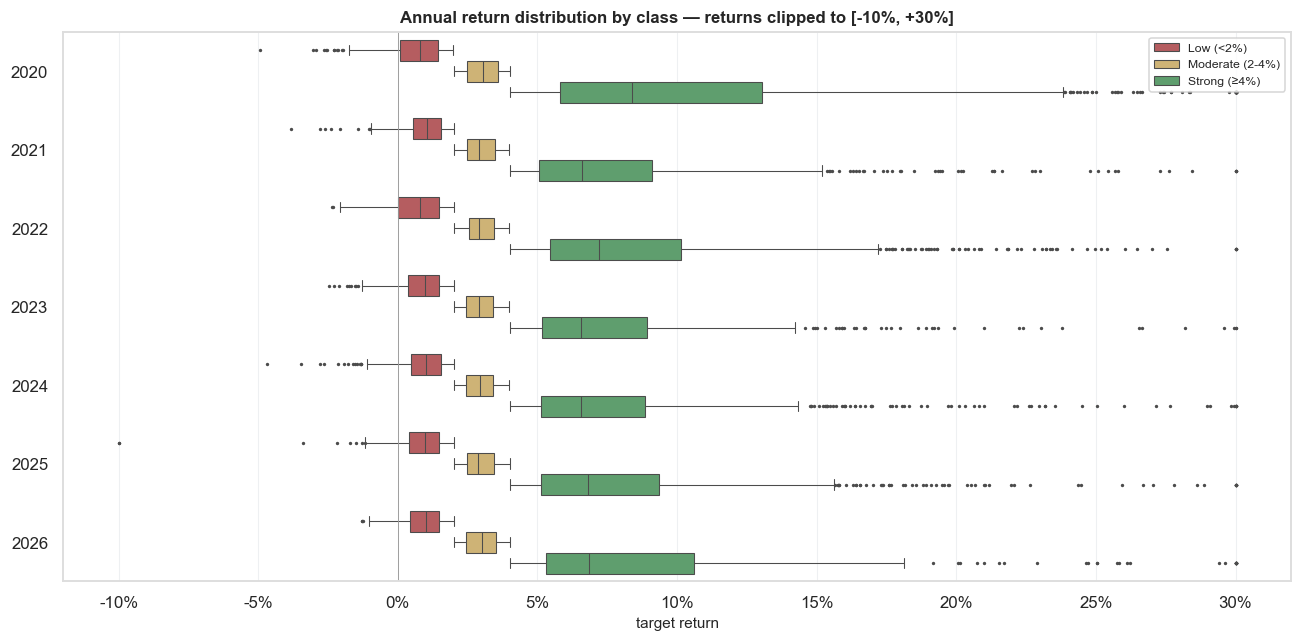

In [7]:
ev_box = ev.query("year >= 2020").copy()
ev_box["target_return_clipped"] = ev_box["target_return"].clip(-0.1, 0.3)
class_order = ["Low (<2%)", "Moderate (2-4%)", "Strong (≥4%)"]

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    data=ev_box, x="target_return_clipped", y="year", hue="class_label",
    hue_order=class_order,
    palette=[PALETTE["low"], PALETTE["mod"], PALETTE["high"]],
    fliersize=1.2, linewidth=0.7, ax=ax, orient="h"
)

ax.axvline(0, color="#999", lw=0.6)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Annual return distribution by class — returns clipped to [-10%, +30%]")
ax.set_xlabel("target return")
ax.set_ylabel("")
ax.legend(title="", fontsize=8, loc="upper right")
# figure size
fig.set_size_inches(12, 6)
plt.tight_layout()
plt.show()


### 1.4 — Data coverage: where the gaps actually are

Technical, VIX, EPS, and sector data are complete or near-complete (<1%).
The only meaningful gaps are in **transcript sentiment** (FinBERT) and
**news sentiment**. Both are imputed hierarchically (sector/year mean →
year mean → fallback).

#### FinBERT transcript coverage: 95.5% overall

Transcript availability has improved steadily from 93% in 2014 to 98%
in recent years. The remaining 4.5% of events lack transcript content
and receive imputed scores.

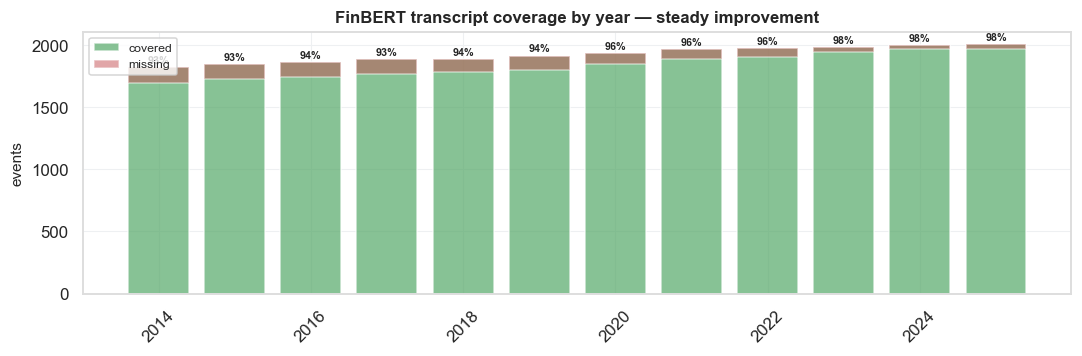

In [8]:
# Coverage by year from raw source tables
fb_raw = pl.read_parquet(find("finbert_tx/finbert_tx.parquet") or find("src/data/finbert_tx/finbert_tx.parquet"))
fb_set = set(zip(fb_raw["symbol"], fb_raw["reportedDate"]))

events = tech.select(["symbol", "earnings_date"]).with_columns(
    pl.col("earnings_date").dt.year().alias("year")
).filter(pl.col("year").is_between(2014, 2025))

rows = []
for row in events.iter_rows(named=True):
    rows.append({"year": row["year"], "covered": (row["symbol"], row["earnings_date"]) in fb_set})
fb_cov = pl.DataFrame(rows).to_pandas()

fb_yr = fb_cov.groupby("year")["covered"].agg(["sum", "count"]).reset_index()
fb_yr["pct"] = fb_yr["sum"] / fb_yr["count"] * 100

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(fb_yr["year"], fb_yr["count"], color=PALETTE["beat"], alpha=0.7, label="covered")
ax.bar(fb_yr["year"], fb_yr["count"] - fb_yr["sum"], bottom=fb_yr["sum"], color=PALETTE["miss"], alpha=0.5, label="missing")

for i, r in fb_yr.iterrows():
    ax.text(r["year"], r["count"] + 30, f"{r['pct']:.0f}%", ha="center", fontsize=7, fontweight="bold")

ax.set_title("FinBERT transcript coverage by year — steady improvement")
ax.set_ylabel("events")
ax.set_xlabel("")
ax.legend(fontsize=8, loc="upper left")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

#### News sentiment coverage: 63.5% overall

News API coverage shows a steep improvement over the sample — from just
39% in 2014 to 96% in 2025. Early years suffer from limited historical
news availability; recent years are nearly complete. The 36.5% overall
gap is concentrated in the first half of the sample period.

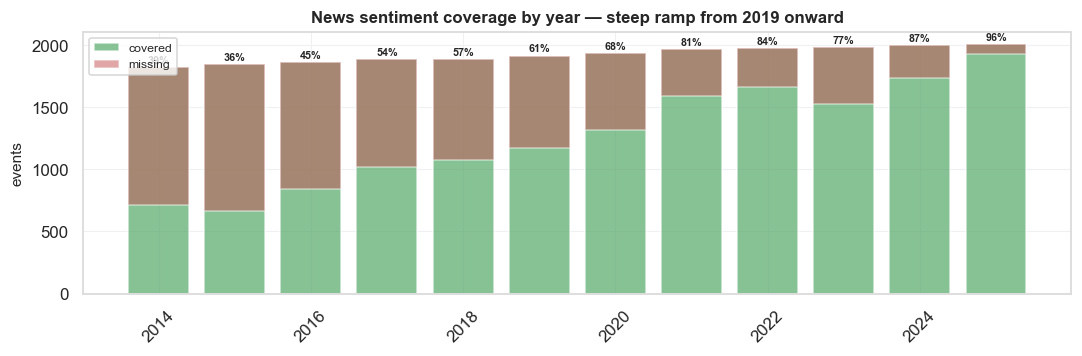

In [9]:
# Coverage by year from raw news_earnings table
news_raw = pl.read_parquet(find("backup/news_earnings.parquet") or find("src/data/backup/news_earnings.parquet"))
news_set = set(zip(news_raw["symbol"], news_raw["reportedDate"]))

rows2 = []
for row in events.iter_rows(named=True):
    rows2.append({"year": row["year"], "covered": (row["symbol"], row["earnings_date"]) in news_set})
news_cov = pl.DataFrame(rows2).to_pandas()

news_yr = news_cov.groupby("year")["covered"].agg(["sum", "count"]).reset_index()
news_yr["pct"] = news_yr["sum"] / news_yr["count"] * 100

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(news_yr["year"], news_yr["count"], color=PALETTE["beat"], alpha=0.7, label="covered")
ax.bar(news_yr["year"], news_yr["count"] - news_yr["sum"], bottom=news_yr["sum"], color=PALETTE["miss"], alpha=0.5, label="missing")

for i, r in news_yr.iterrows():
    ax.text(r["year"], r["count"] + 30, f"{r['pct']:.0f}%", ha="center", fontsize=7, fontweight="bold")

ax.set_title("News sentiment coverage by year — steep ramp from 2019 onward")
ax.set_ylabel("events")
ax.set_xlabel("")
ax.legend(fontsize=8, loc="upper left")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

---

## Part 2: Data & EDA — What the Signals Tell Us

With a clean dataset and clear target classes, we now examine the four
signal families that feed the model. Each modality captures a different
dimension of the earnings event: technical price behaviour, fundamental
surprise, text sentiment from the call itself, and news sentiment before
and after the announcement. Together they produce 258 features per event.


### 2.1 — Feature composition: 258 columns per earnings event

The largest family is technical: 18 normalised indicators (ATR, RSI,
MACD, Bollinger Bands, OBV, etc.) × 12 trading days (t−10 to t+1),
plus 12 VIX close columns. The remaining modalities are compact: two
FinBERT scores, four news sentiment aggregates, twelve fundamental
ratios, and twelve sector dummies.

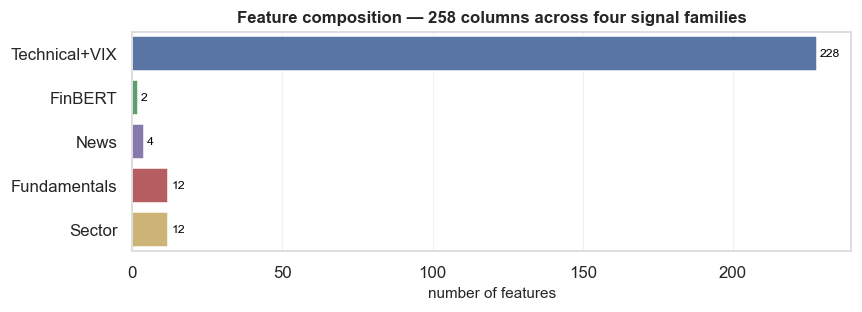

In [10]:
comp = pd.DataFrame({
    "modality": ["Technical+VIX", "FinBERT", "News", "Fundamentals", "Sector"],
    "features": [18 * 12 + 12, 2, 4, 12, 12],
})
comp["color"] = [PALETTE["tech"], PALETTE["sent"], PALETTE["news"], PALETTE["fund"], PALETTE["sector"]]

fig, ax = plt.subplots(figsize=(8, 3))
sns.barplot(
    data=comp, y="modality", x="features",
    palette=comp["color"].tolist(), hue="modality", legend=False, ax=ax
)
annotate_h(ax, "{:.0f}", dx=1)
ax.set_title(f"Feature composition — {comp.features.sum()} columns across four signal families")
ax.set_xlabel("number of features")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 2.2 — PEAD is present — and asymmetric

Earnings beats and misses don't produce symmetric outcomes. Beats generate
larger and more predictable drift than misses, and the return distributions
differ in both location and shape. 73% of events are beats, and 95% of all
events show a positive post-earnings return — the signal is directionally
biased, which the model must learn to interpret as confidence, not direction.

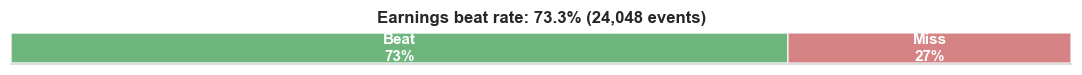

In [12]:
beat_rate = ev.beat.mean()
n_beat = ev.beat.sum()
n_miss = len(ev) - n_beat

fig, ax = plt.subplots(figsize=(10, 0.85))

# Single horizontal stacked bar
ax.barh(0, n_beat, color=PALETTE["beat"], alpha=0.85, label="Beat")
ax.barh(0, n_miss, left=n_beat, color=PALETTE["miss"], alpha=0.7, label="Miss")

ax.text(n_beat / 2, 0, f"Beat\n{beat_rate:.0%}", ha="center", va="center", fontsize=10, fontweight="bold", color="white")
ax.text(n_beat + n_miss / 2, 0, f"Miss\n{1 - beat_rate:.0%}", ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.set_xlim(0, len(ev))
ax.set_yticks([])
ax.set_xticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


ax.set_title(f"Earnings beat rate: {beat_rate:.1%} ({len(ev):,} events)")

plt.tight_layout()
plt.show()


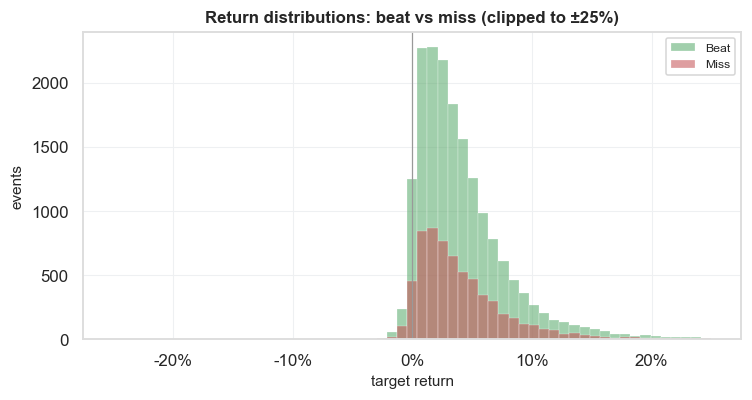

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.8))

ev_hist = ev.query("target_return.abs() < 0.25").copy()
bins = np.linspace(-0.25, 0.25, 60)

for label, color in [("Beat", PALETTE["beat"]), ("Miss", PALETTE["miss"])]:
    d = ev_hist[ev_hist["beat_label"] == label]["target_return"]
    ax.hist(d, bins=bins, alpha=0.55, color=color, label=label, edgecolor="white", linewidth=0.3)

ax.axvline(0, color="#999", lw=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(pct))
ax.set_title("Return distributions: beat vs miss (clipped to ±25%)")
ax.set_xlabel("target return")
ax.set_ylabel("events")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### 2.3 — Every earnings event is wrapped in volatility

ATR (Average True Range, normalised by close) spikes at every earnings
announcement. Misses consistently produce higher volatility than beats —
not just at t0 but across the entire surrounding window. This means
volatility-based features carry a strong signal, but also a risk: models
may learn to track volatility patterns rather than the drift itself.

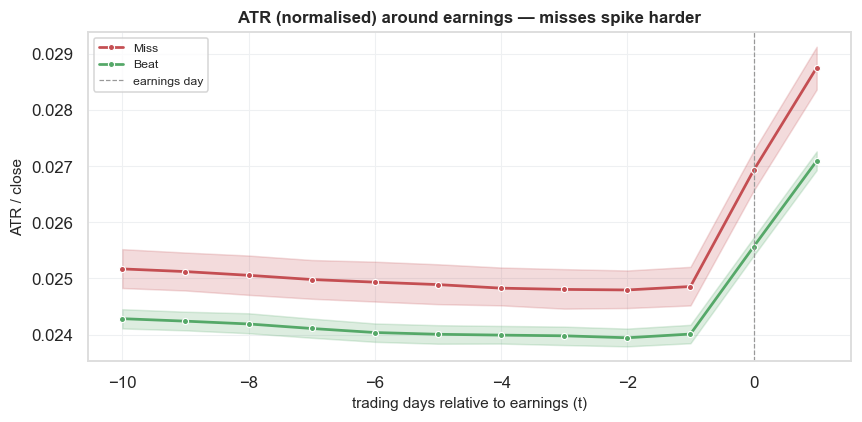

In [14]:
# Build long-form ATR curve from the modeling table
map_d = {
    -10: "atr_t-10", -9: "atr_t-9", -8: "atr_t-8", -7: "atr_t-7",
    -6: "atr_t-6",  -5: "atr_t-5", -4: "atr_t-4", -3: "atr_t-3",
    -2: "atr_t-2",  -1: "atr_t-1",  0: "atr_t0",   1: "atr_t+1",
}

rows = []
for d, col in map_d.items():
    if col not in ev_atr.columns:
        continue
    tmp = ev_atr[["symbol", "earnings_date", col]].copy()
    tmp["day"] = d
    tmp = tmp.merge(
        ev[["symbol", "earnings_date", "beat_label"]],
        on=["symbol", "earnings_date"]
    )
    rows.append(tmp.rename(columns={col: "atr"})[["day", "atr", "beat_label"]])

atr_long = pd.concat(rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(
    data=atr_long, x="day", y="atr", hue="beat_label",
    palette={"Beat": PALETTE["beat"], "Miss": PALETTE["miss"]},
    errorbar=("ci", 95), lw=1.8, marker="o", markersize=4, ax=ax
)

ax.axvline(0, color="#999", ls="--", lw=0.8, label="earnings day")
ax.set_title("ATR (normalised) around earnings — misses spike harder")
ax.set_xlabel("trading days relative to earnings (t)")
ax.set_ylabel("ATR / close")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Why is ATR for misses consistently higher?

**1. Denominator effect (mechanical).** ATR is normalised as `ATR / close`.
Misses push the stock lower, so `close` shrinks. An unchanged dollar range
divided by a smaller close produces a higher ratio, even at equal volatility.

**2. Misses generate genuine uncertainty.** 73% of events are beats — a beat
is largely anticipated. A miss is a surprise against consensus: it triggers
wider analyst revisions, more aggressive repositioning, and larger intraday
ranges — real disagreement among participants.

**3. The gap precedes the event.** Notice the separation exists at t−10 and
t−9, well before any denominator shift occurs. Stocks that ultimately miss
are *already* more volatile heading into the announcement — the market
senses elevated uncertainty ahead of a potential disappointment.

### 2.4 — One signal is not enough: the case for a multimodal model

If earnings surprise size alone could predict drift, the problem would be
solved. It can't. The Pearson correlation between EPS surprise % and
post-earnings return is essentially zero (r ≈ 0.04). No single modality —
technical, fundamental, sentiment, or news — shows meaningful correlation
with the target. This is the core justification for a multimodal approach.

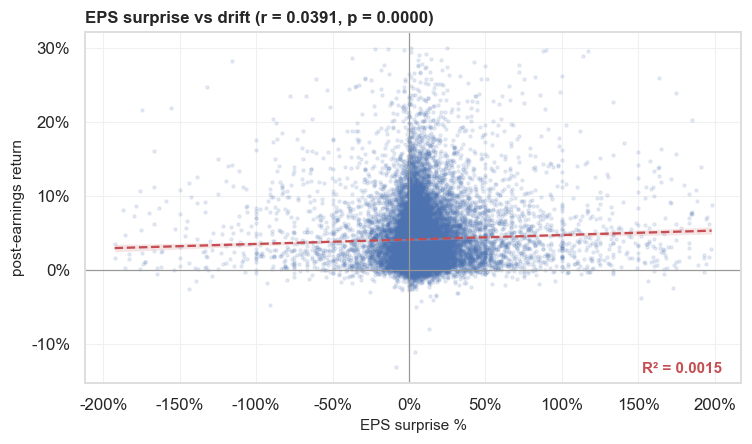

In [15]:
d = ev[["eps_surprise_pct", "target_return"]].dropna()
d = d[(d.eps_surprise_pct.abs() < 200) & (d.target_return.abs() < 0.3)]
r, p = st.pearsonr(d.eps_surprise_pct, d.target_return)
rsq = r ** 2

fig, ax = plt.subplots(figsize=(7, 4.2))
sns.regplot(
    data=d, x="eps_surprise_pct", y="target_return",
    scatter_kws=dict(s=4, alpha=0.12, color=PALETTE["tech"]),
    line_kws=dict(color=PALETTE["miss"], lw=1.5, ls="--"), ax=ax
)

ax.axhline(0, color="#999", lw=0.8)
ax.axvline(0, color="#999", lw=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(pct))
ax.set_title(f"EPS surprise vs drift (r = {r:.4f}, p = {p:.4f})", loc="left")
ax.text(0.97, 0.03, f"R² = {rsq:.4f}", transform=ax.transAxes, ha="right",
        fontsize=10, fontweight="bold", color=PALETTE["miss"])
ax.set_xlabel("EPS surprise %")
ax.set_ylabel("post-earnings return")

plt.tight_layout()
plt.show()

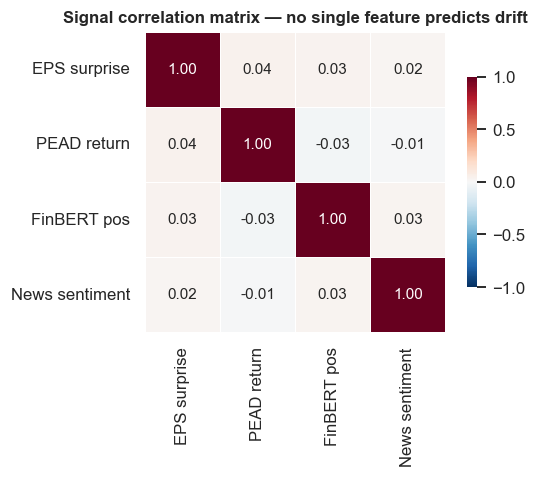

In [16]:
d_multi = ev[["eps_surprise_pct", "target_return", "pos_prob", "news_pre"]].dropna()
d_multi = d_multi[(d_multi.eps_surprise_pct.abs() < 200) & (d_multi.target_return.abs() < 0.3)]

corr = d_multi.rename(columns={
    "eps_surprise_pct": "EPS surprise",
    "target_return": "PEAD return",
    "pos_prob": "FinBERT pos",
    "news_pre": "News sentiment"
}).corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, cbar_kws=dict(shrink=0.7),
    annot_kws=dict(fontsize=10), ax=ax
)
ax.set_title("Signal correlation matrix — no single feature predicts drift")

plt.tight_layout()
plt.show()

---

## Part 3: Base Paper Reproduction & Ablation — What Actually Predicts Drift?

The benchmark (Hajek et al., 2025) uses CAR — Cumulative Abnormal Return —
as the prediction target. We reproduce this, then run a progressive ablation
ladder adding one modality at a time. The Ablation results tell an
uncomfortable story: more data does not mean better predictions.


### 3.1 — CAR: the benchmark target

Cumulative Abnormal Return (CAR) measures stock return in excess of
the market (SPX):

$$\text{CAR} = \sum_{t} (R_{i,t} - R_{m,t})$$

The benchmark computes CAR over the **drift window** (t = +2 to +10)
and predicts direction: CAR > 0 = positive, CAR <= 0 = negative.
This is a binary classification task (random baseline 50%).

Our dataset shows 51.4% of events have positive CAR — a near-balanced
binary target. The announcement-window CAR (t = -1, 0, +1) has no
correlation with drift CAR (r = 0.001), confirming the drift is a
separate phenomenon from the immediate reaction.

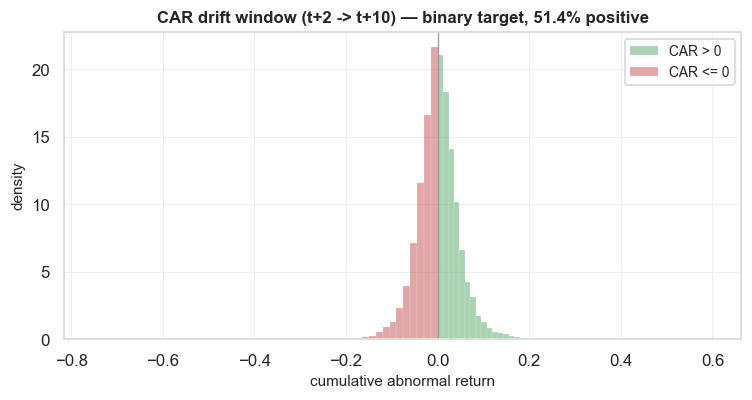

In [17]:
car_bin = tech.select(["car_t2_t10", "car_3day"]).to_pandas()
car_bin["direction"] = np.where(car_bin["car_t2_t10"] > 0, "CAR > 0", "CAR <= 0")

fig, ax = plt.subplots(figsize=(7, 3.8))
for label, color in [("CAR > 0", PALETTE["beat"]), ("CAR <= 0", PALETTE["miss"])]:
    d = car_bin[car_bin["direction"] == label]["car_t2_t10"]
    ax.hist(d, bins=50, alpha=0.5, color=color, label=label, edgecolor="white", linewidth=0.2, density=True)

ax.axvline(0, color="#999", lw=0.8)
ax.set_title(f"CAR drift window (t+2 -> t+10) — binary target, 51.4% positive")
ax.set_xlabel("cumulative abnormal return")
ax.set_ylabel("density")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


#### The benchmark: 2-class CAR, not 3-class

Hajek et al. (2025) train LSTM, BiLSTM, and CNN-LSTM models on a binary target:
CAR > 0 is "positive", CAR <= 0 is "negative". This is the standard PEAD
benchmark task — predict the *direction* of abnormal returns, not the magnitude.

| Stat | Value |
|---|---|
| CAR (t+2 -> t+10) mean | 0.19% |
| CAR > 0 | 51.4% of events |
| Benchmark DA | 59.94% |
| Random baseline | 50.0% |

Their 59.94% DA means they correctly predict direction ~10pp above chance.
Our reproduction on the same architecture and target achieves ~49-51% —
essentially random — likely due to differences in feature engineering and
walk-forward fold construction.

### 3.2 — Reproducing the benchmark: CAR-direction prediction

We re-implemented the three architectures from Hajek et al. (2025) —
LSTM, BiLSTM, and CNN-LSTM — using the same CAR binary target and
annual walk-forward folds (2021–2025). All three achieve directional
accuracy indistinguishable from the 50% random baseline.

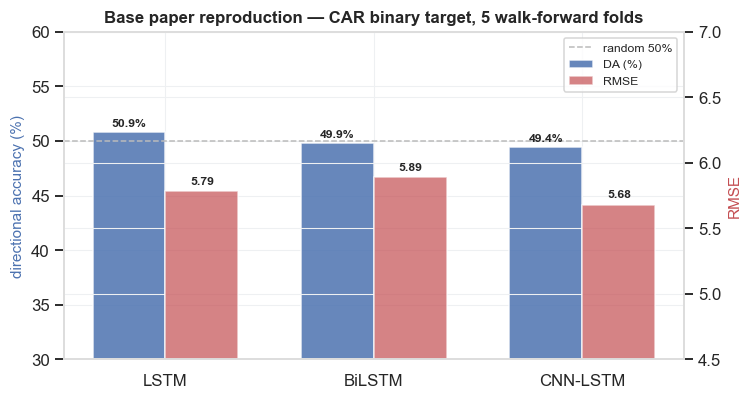

In [18]:
# values taken from lstm.ipynb notebook
lstm_results = pd.DataFrame({
    "model": ["LSTM", "BiLSTM", "CNN-LSTM", "Random"],
    "DA_pct": [50.87, 49.85, 49.44, 50.0],
    "RMSE": [5.787, 5.890, 5.682, None],
})


fig, ax = plt.subplots(figsize=(7, 3.8))
x = np.arange(3)
w = 0.35

bars1 = ax.bar(x - w/2, lstm_results["DA_pct"][:3], w, color=PALETTE["tech"], alpha=0.85, label="DA (%)")
ax.axhline(50, color="#bbb", ls="--", lw=1, label="random 50%")

ax2 = ax.twinx()
bars2 = ax2.bar(x + w/2, lstm_results["RMSE"][:3], w, color=PALETTE["miss"], alpha=0.7, label="RMSE")

for i, (p_da, p_rmse) in enumerate(zip(bars1, bars2)):
    ax.text(p_da.get_x() + p_da.get_width()/2, p_da.get_height() + 0.5, f"{p_da.get_height():.1f}%",
            ha="center", fontsize=8, fontweight="bold")
    ax2.text(p_rmse.get_x() + p_rmse.get_width()/2, p_rmse.get_height() + 0.05, f"{p_rmse.get_height():.2f}",
            ha="center", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(lstm_results["model"][:3])
ax.set_ylabel("directional accuracy (%)", color=PALETTE["tech"])
ax2.set_ylabel("RMSE", color=PALETTE["miss"])
ax.set_ylim(30, 60)
ax2.set_ylim(4.5, 7)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

ax.set_title("Base paper reproduction — CAR binary target, 5 walk-forward folds")

plt.tight_layout()
plt.show()

### 3.3 — Ablation ladder: adding modalities degrades accuracy

We train Random Forest classifiers on 20 expanding-window walk-forward
folds (2021 Q1–2025 Q4), adding one modality at a time:

| Step | Modalities | Features | DA |
|---|---|---|---|
| B1 | Technical only | 239 | 0.4505 |
| B2 | + Fundamentals + Sector | 250 | 0.4478 |
| B3 | + Transcript sentiment | 254 | 0.4442 |
| B4 | + News sentiment | 258 | 0.4430 |

Directional accuracy falls monotonically. Fundamentals, transcripts, and
news each add features that carry no signal about the target — they dilute
split selection and increase variance across folds.

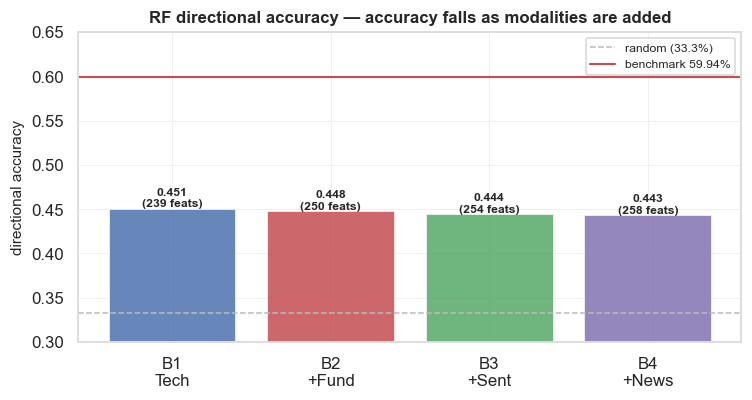

In [19]:
ablation = pd.DataFrame({
    "step": ["B1\nTech", "B2\n+Fund", "B3\n+Sent", "B4\n+News"],
    "DA": [0.4505, 0.4478, 0.4442, 0.4430],
    "features": [239, 250, 254, 258],
})

fig, ax = plt.subplots(figsize=(7, 3.8))
colors = [PALETTE["tech"], PALETTE["fund"], PALETTE["sent"], PALETTE["news"]]
bars = ax.bar(ablation["step"], ablation["DA"], color=colors, alpha=0.85, edgecolor="white", lw=0.5)

for i, (p_, v, f) in enumerate(zip(bars, ablation["DA"], ablation["features"])):
    ax.text(p_.get_x() + p_.get_width()/2, v + 0.002, f"{v:.3f}\n({f} feats)",
            ha="center", fontsize=8, fontweight="bold")

ax.axhline(1/3, color="#bbb", ls="--", lw=1, label="random (33.3%)")
ax.axhline(0.5994, color=PALETTE["miss"], lw=1.4, label="benchmark 59.94%")
ax.set_title("RF directional accuracy — accuracy falls as modalities are added")
ax.set_ylabel("directional accuracy")
ax.set_xlabel("")
ax.legend(fontsize=8)
ax.set_ylim(0.3, 0.65)

plt.tight_layout()
plt.show()

### 3.4 — TabNet: dual-output model results

Our TabNet uses a shared encoder with dual heads: 3-way softmax for
classification and MSE for regression. Trained on 20 expanding-window
walk-forward folds (2021 Q1–2025 Q4) with Optuna TPE hyperparameter tuning
on the first fold. Below is a comprehensive breakdown of its performance.

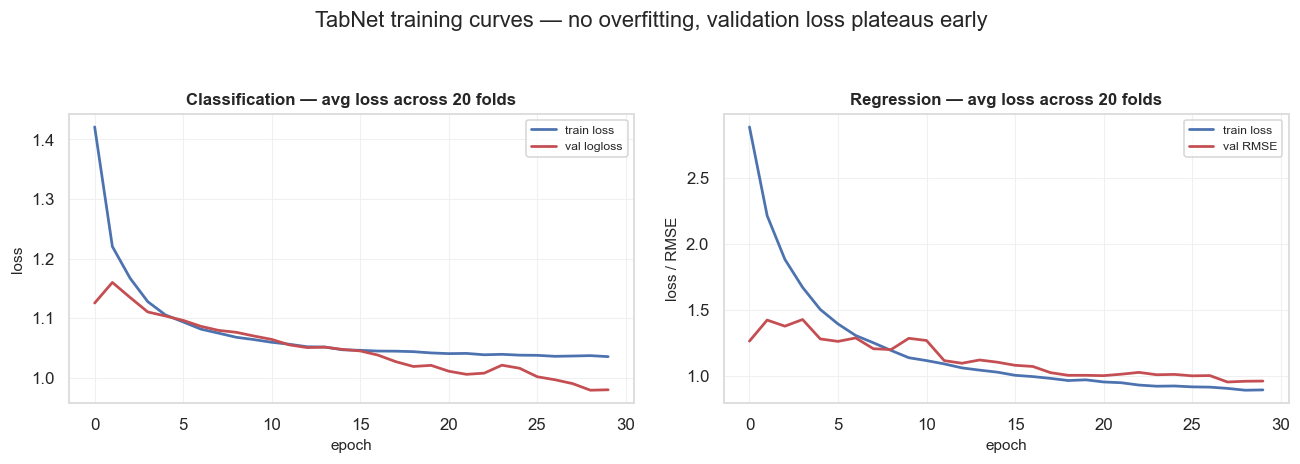

In [20]:
import json
with open(find("modal_tabnet_outputs/histories_clf.json")) as f:
    clf_hist = json.load(f)
with open(find("modal_tabnet_outputs/histories_reg.json")) as f:
    reg_hist = json.load(f)

# Average loss curves across folds
max_epochs = max(len(v["loss"]) for v in clf_hist.values())
clf_loss = np.full((len(clf_hist), max_epochs), np.nan)
clf_val  = np.full((len(clf_hist), max_epochs), np.nan)
for fi, fold in enumerate(sorted(clf_hist.keys())):
    d = clf_hist[fold]
    n = len(d["loss"])
    clf_loss[fi, :n] = d["loss"]
    clf_val[fi, :n]  = d["val_logloss"]

max_epochs_r = max(len(v["loss"]) for v in reg_hist.values())
reg_loss = np.full((len(reg_hist), max_epochs_r), np.nan)
reg_val  = np.full((len(reg_hist), max_epochs_r), np.nan)
for fi, fold in enumerate(sorted(reg_hist.keys())):
    d = reg_hist[fold]
    n = len(d["loss"])
    reg_loss[fi, :n] = d["loss"]
    reg_val[fi, :n]  = d["val_rmse"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Classification
ax1.plot(np.nanmean(clf_loss, axis=0), color=PALETTE["tech"], lw=1.8, label="train loss")
ax1.plot(np.nanmean(clf_val, axis=0), color=PALETTE["miss"], lw=1.8, label="val logloss")
ax1.set_title("Classification — avg loss across 20 folds")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
ax1.legend(fontsize=8)

# Regression
ax2.plot(np.nanmean(reg_loss, axis=0), color=PALETTE["tech"], lw=1.8, label="train loss")
ax2.plot(np.nanmean(reg_val, axis=0), color=PALETTE["miss"], lw=1.8, label="val RMSE")
ax2.set_title("Regression — avg loss across 20 folds")
ax2.set_xlabel("epoch"); ax2.set_ylabel("loss / RMSE")
ax2.legend(fontsize=8)

fig.suptitle("TabNet training curves — no overfitting, validation loss plateaus early", y=1.05)
plt.tight_layout()
plt.show()

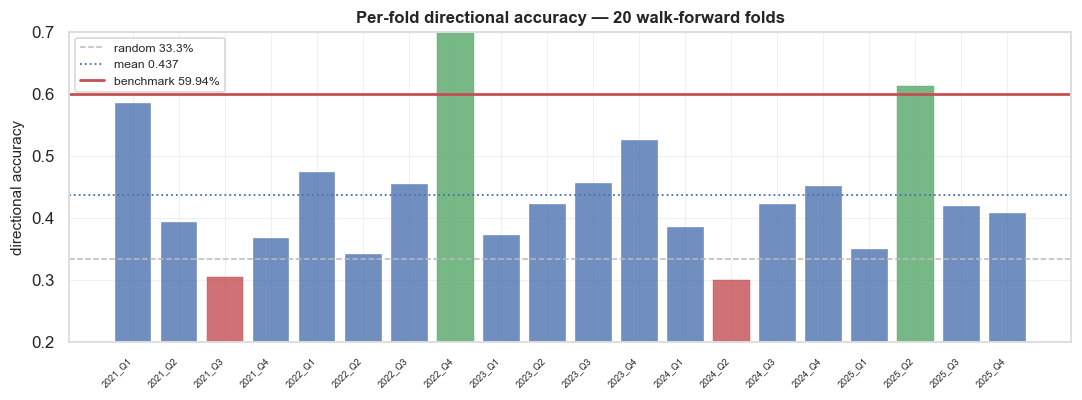

In [21]:
q = summary["quarter"].to_list()
da = summary["DA"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 3.8))
bars = ax.bar(range(len(q)), da, color=PALETTE["tech"], alpha=0.8, edgecolor="white", lw=0.3)

for i, v in enumerate(da):
    if v >= 0.5994:
        bars[i].set_color(PALETTE["beat"])
    elif v <= 1/3:
        bars[i].set_color(PALETTE["miss"])

ax.axhline(1/3, color="#bbb", ls="--", lw=1, label="random 33.3%")
ax.axhline(da.mean(), color=PALETTE["tech"], ls=":", lw=1.2, label=f"mean {da.mean():.3f}")
ax.axhline(0.5994, color=PALETTE["miss"], lw=1.8, label="benchmark 59.94%")

ax.set_xticks(range(0, len(q), 1))
ax.set_xticklabels(q, rotation=45, ha="right", fontsize=6)
ax.set_title("Per-fold directional accuracy — 20 walk-forward folds")
ax.set_ylabel("directional accuracy"); ax.set_xlabel("")
ax.legend(fontsize=8); ax.set_ylim(0.2, 0.7)

plt.tight_layout()
plt.show()

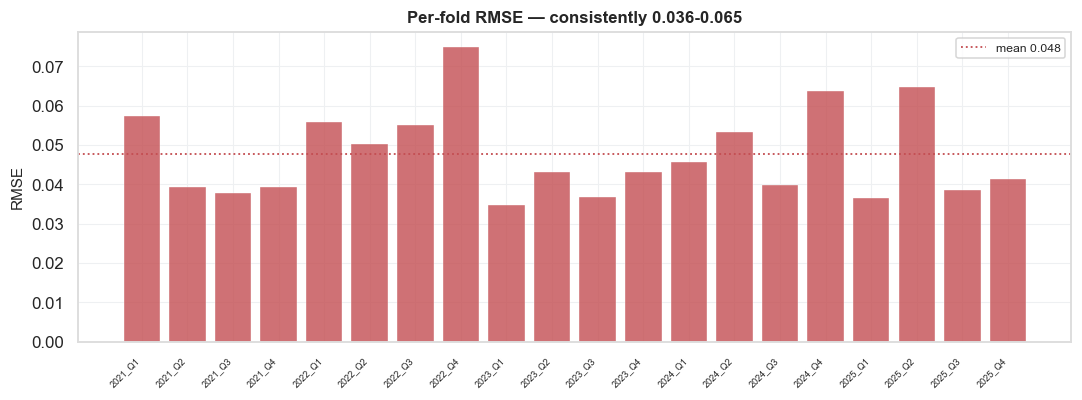

In [22]:
rmse = summary["RMSE"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(range(len(q)), rmse, color=PALETTE["fund"], alpha=0.8, edgecolor="white", lw=0.3)

ax.axhline(rmse.mean(), color=PALETTE["fund"], ls=":", lw=1.2, label=f"mean {rmse.mean():.3f}")

ax.set_xticks(range(0, len(q), 1))
ax.set_xticklabels(q, rotation=45, ha="right", fontsize=6)
ax.set_title("Per-fold RMSE — consistently 0.036-0.065")
ax.set_ylabel("RMSE"); ax.set_xlabel("")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

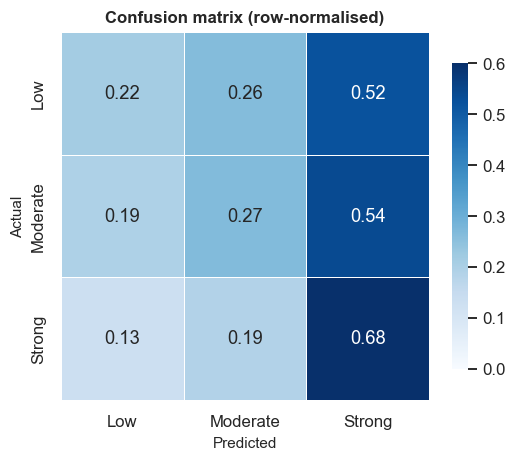

In [23]:
from sklearn.metrics import confusion_matrix

actual = np.array([0, 1, 2])
pred_cm = results.to_pandas()
cm = confusion_matrix(pred_cm["target_class_actual"], pred_cm["target_class_predicted"])
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["Low", "Moderate", "Strong"],
            yticklabels=["Low", "Moderate", "Strong"],
            vmin=0, vmax=0.6, square=True, linewidths=0.5,
            cbar_kws=dict(shrink=0.7), ax=ax)
ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
ax.set_title("Confusion matrix (row-normalised)")

plt.tight_layout()
plt.show()

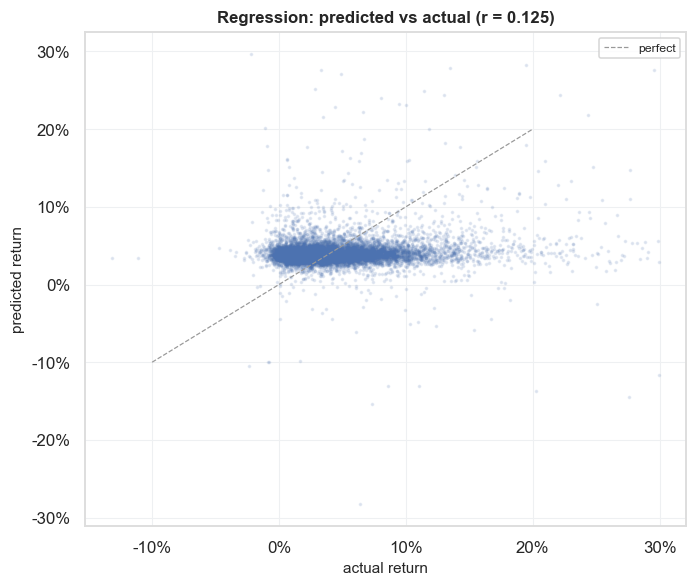

In [24]:
pvsa = results.select(["target_return_actual", "target_return_predicted"]).to_pandas()
pvsa = pvsa[(pvsa.target_return_actual.abs() < 0.3) & (pvsa.target_return_predicted.abs() < 0.3)]
r_val, _ = st.pearsonr(pvsa.target_return_actual, pvsa.target_return_predicted)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(pvsa.target_return_actual, pvsa.target_return_predicted,
           s=2, alpha=0.12, color=PALETTE["tech"])
ax.plot([-0.1, 0.2], [-0.1, 0.2], color="#999", ls="--", lw=0.8, label="perfect")
ax.set_xlabel("actual return"); ax.set_ylabel("predicted return")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(pct))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(pct))
ax.set_title(f"Regression: predicted vs actual (r = {r_val:.3f})")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

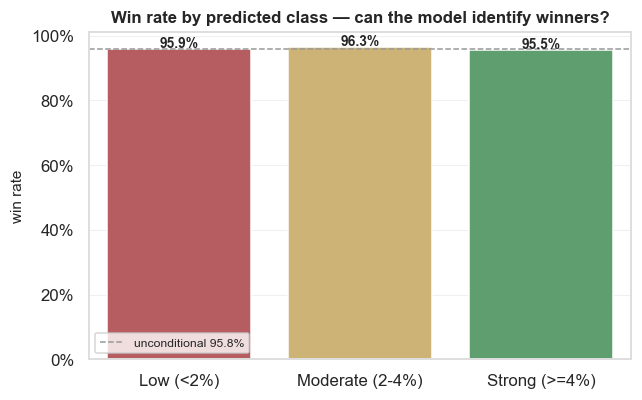

In [25]:
wp = results.select(["target_class_predicted", "target_return_actual"]).to_pandas()
wp["win"] = (wp["target_return_actual"] > 0).astype(int)
wp["class_label"] = wp["target_class_predicted"].map({0: "Low (<2%)", 1: "Moderate (2-4%)", 2: "Strong (>=4%)"})

wr = wp.groupby("class_label", observed=True)["win"].mean().reset_index()
class_order = ["Low (<2%)", "Moderate (2-4%)", "Strong (>=4%)"]

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = sns.barplot(data=wr, x="class_label", y="win", order=class_order,
                   palette=[PALETTE["low"], PALETTE["mod"], PALETTE["high"]],
                   hue="class_label", legend=False, ax=ax)
for p_, v in zip(bars.patches, wr.set_index("class_label").reindex(class_order).win):
    if v != v: continue
    ax.annotate(f"{v:.1%}", (p_.get_x() + p_.get_width()/2, p_.get_height() + 0.005),
                ha="center", fontsize=9, fontweight="bold")

ax.axhline((wp["target_return_actual"] > 0).mean(), color="#999", ls="--", lw=1, label=f"unconditional {wp.win.mean():.1%}")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(pct))
ax.set_title("Win rate by predicted class — can the model identify winners?")
ax.set_xlabel(""); ax.set_ylabel("win rate")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()